<a href="https://colab.research.google.com/github/NatGN/Practicas-de-seminario-de-mineria-de-datos/blob/main/REGRESI%C3%93N_LINEAL_Ejerc3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score #Metricas de evaluación


In [6]:
# Carga y exploración inicial de datos
df = pd.read_csv('PracticaExamenes.csv')
df.head()

,horas,puntuacion
0,3,64
1,4,67
2,6,76
3,3,65
4,5,72


In [7]:
# Limpiar nombres de columnas por si tienen espacios en blanco
df.columns = [c.strip() for c in df.columns]

In [8]:
#Información Básica del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   horas       150 non-null    int64
 1   puntuacion  150 non-null    int64
dtypes: int64(2)
memory usage: 2.5 KB


In [9]:
#Estadisticas descriptivas para entender la distribucion
df.describe()

,horas,puntuacion
count,150.000000,150.000000
mean,3.513333,65.360000
std,1.759868,9.277439
min,1.000000,50.000000
25%,2.000000,58.000000
50%,4.000000,66.000000
75%,5.000000,73.000000
max,6.000000,80.000000


In [10]:
#Preparación de los datos
#Seleccionamos las variables:
#X: independiente (predictora) - Horas
#y: dependiente (a predecir) - Puntuación

#Extraemos los valores como arrays de numpy para el modelo
X = df[['horas']].values  # Variable independiente
y = df[['puntuacion']].values  # Variable dependiente

In [11]:
# 2. Análisis de regresión lineal
modelo_estudios = LinearRegression()
modelo_estudios.fit(X, y)


LinearRegression()

In [12]:
# Parámetros de la ecuación
m = modelo_estudios.coef_[0]
b = modelo_estudios.intercept_


In [13]:
# 3. Calcular R² y predicciones
y_pred = modelo_estudios.predict(X)
r2 = r2_score(y, y_pred)

print(f"--- Parámetros del Modelo ---")
print(f"Pendiente (m): {m[0]:.2f}")
print(f"Intercepto (b): {b[0]:.2f}")
print(f"Coeficiente R²: {r2:.2f}")

--- Parámetros del Modelo ---
Pendiente (m): 5.21
Intercepto (b): 47.06
Coeficiente R²: 0.98


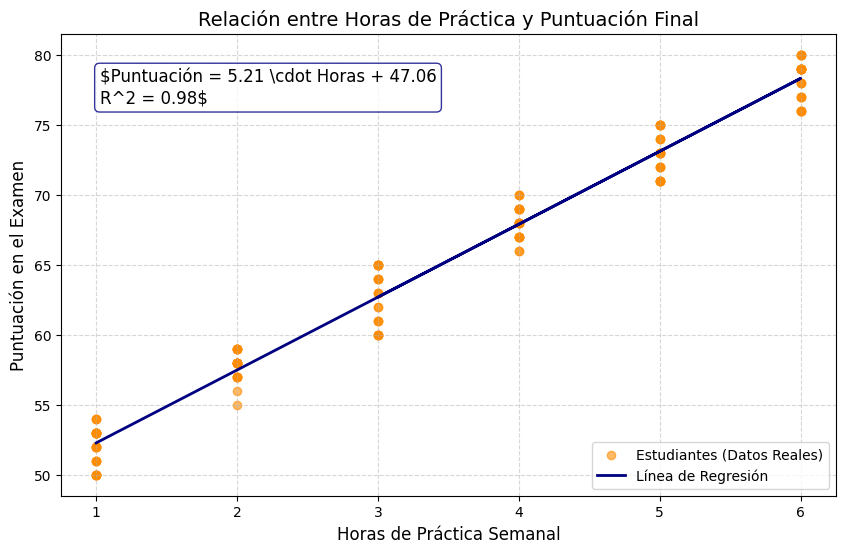

In [16]:
# 4. Visualización de la relación
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='darkorange', alpha=0.6, label='Estudiantes (Datos Reales)')
plt.plot(X, y_pred, color='navy', linewidth=2, label='Línea de Regresión')

# Añadir ecuación y R² al gráfico
texto_resumen = f'$Puntuación = {m[0]:.2f} \\cdot Horas + {b[0]:.2f}\nR^2 = {r2:.2f}$'
plt.annotate(texto_resumen, xy=(0.05, 0.85), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle="round", fc="white", ec="navy", alpha=0.8))

plt.title('Relación entre Horas de Práctica y Puntuación Final', fontsize=14)
plt.xlabel('Horas de Práctica Semanal', fontsize=12)
plt.ylabel('Puntuación en el Examen', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

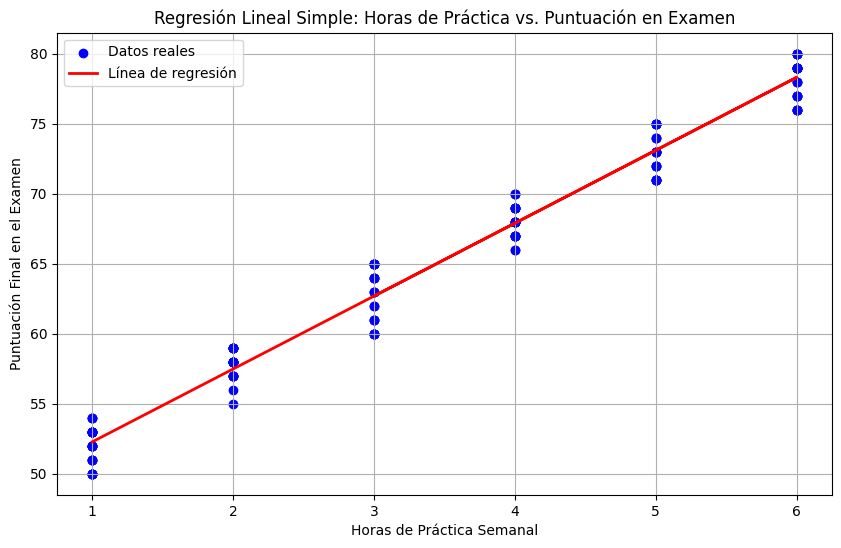

In [17]:
# 5. Visualizar la relación
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Datos reales')
plt.plot(X, y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.title('Regresión Lineal Simple: Horas de Práctica vs. Puntuación en Examen')
plt.xlabel('Horas de Práctica Semanal')
plt.ylabel('Puntuación Final en el Examen')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# 5. Función de predicción
def predecir_nota(horas):
    """
    Predice la puntuación basada en las horas de práctica.
    """
    puntuacion = modelo_estudios.predict([[horas]])
    return puntuacion[0]

In [19]:
# Ejemplo de uso
nuevas_horas = 8
nota_estimada = predecir_nota(nuevas_horas)
print(f"\n--- Predicción ---")
print(f"Para {nuevas_horas} horas de práctica, la puntuación esperada es: {nota_estimada[0]:.2f}")



--- Predicción ---
Para 8 horas de práctica, la puntuación esperada es: 88.73
